Epoch 25/150, Loss: 0.2090
Epoch 50/150, Loss: 0.1582
Epoch 75/150, Loss: 0.1388
Epoch 100/150, Loss: 0.1293
Epoch 125/150, Loss: 0.1203
Epoch 150/150, Loss: 0.1057
Test Accuracy: 95.40%


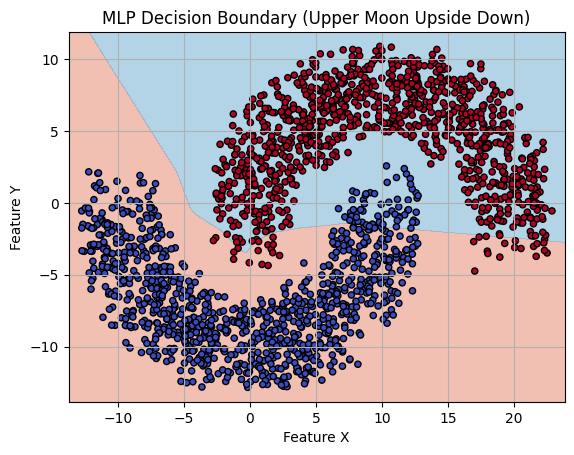

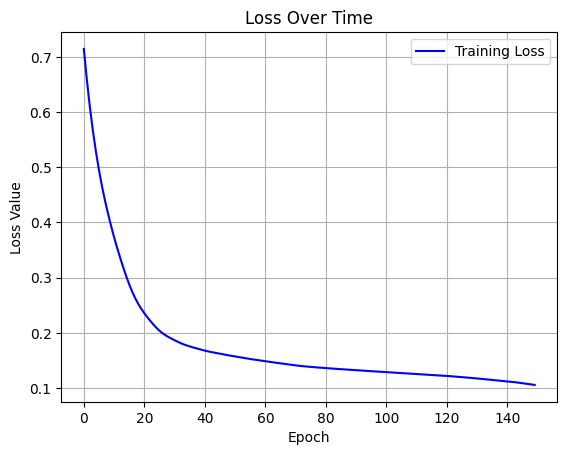

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split

# Function to create the double moon dataset with the upper moon upside down
def create_double_moon(n_samples=1000, r=10, w=2, d=-1):
    """
    Creates two crescent-shaped clusters; upper moon is upside down.
    n_samples: total number of points
    r: radius of the moons
    w: width of the moons
    d: vertical separation (negative for overlap)
    """
    half_samples = n_samples // 2
    
    # Upper moon (label 0) - upside down
    angle_upper = np.random.uniform(0, np.pi, half_samples)
    x_upper = r * np.cos(angle_upper) + np.random.uniform(-w/2, w/2, half_samples)
    y_upper = -r * np.sin(angle_upper) + np.random.uniform(-w/2, w/2, half_samples)  # Negate sin to flip upside down
    upper_moon = np.column_stack((x_upper, y_upper))
    
    # Lower moon (label 1) - normal orientation
    angle_lower = np.random.uniform(0, np.pi, half_samples)
    x_lower = r * np.cos(angle_lower) + r + np.random.uniform(-w/2, w/2, half_samples)
    y_lower = r * np.sin(angle_lower) + d + np.random.uniform(-w/2, w/2, half_samples)
    lower_moon = np.column_stack((x_lower, y_lower))
    
    # Combine data and labels
    dataset = np.vstack((upper_moon, lower_moon)).astype(np.float32)
    targets = np.hstack((np.zeros(half_samples), np.ones(half_samples))).astype(np.float32)
    
    return dataset, targets

# Define the MLP model
class NeuralNet(nn.Module):
    def __init__(self, input_size=2, hidden_layers=[12, 8]):
        super(NeuralNet, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden_layers[0]),
            nn.ReLU(),
            nn.Linear(hidden_layers[0], hidden_layers[1]),
            nn.ReLU(),
            nn.Linear(hidden_layers[1], 1)
        )
    
    def forward(self, x):
        return torch.sigmoid(self.layers(x))

# Training loop
def train_network(model, loss_fn, opt, X_tr, y_tr, num_epochs=150):
    loss_values = []
    model.train()
    for epoch in range(num_epochs):
        opt.zero_grad()
        inputs = torch.from_numpy(X_tr)
        targets = torch.from_numpy(y_tr).view(-1, 1)
        predictions = model(inputs)
        loss = loss_fn(predictions, targets)
        loss.backward()
        opt.step()
        loss_values.append(loss.item())
        if (epoch + 1) % 25 == 0:
            print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {loss.item():.4f}")
    return loss_values

# Evaluate model accuracy
def test_model(model, X_te, y_te):
    model.eval()
    with torch.no_grad():
        inputs = torch.from_numpy(X_te)
        targets = torch.from_numpy(y_te).view(-1, 1)
        predictions = model(inputs)
        binary_preds = (predictions >= 0.5).float()
        accuracy = (binary_preds == targets).sum().item() / len(y_te)
        print(f"Test Accuracy: {accuracy * 100:.2f}%")
    return accuracy

# Visualize decision boundary
def show_decision_boundary(model, X, y):
    step_size = 0.05
    x_range = np.arange(X[:, 0].min() - 1, X[:, 0].max() + 1, step_size)
    y_range = np.arange(X[:, 1].min() - 1, X[:, 1].max() + 1, step_size)
    grid_x, grid_y = np.meshgrid(x_range, y_range)
    grid_points = np.c_[grid_x.ravel(), grid_y.ravel()].astype(np.float32)
    
    model.eval()
    with torch.no_grad():
        Z = model(torch.from_numpy(grid_points)).numpy().reshape(grid_x.shape)
    
    plt.figure()
    plt.contourf(grid_x, grid_y, Z, levels=[0, 0.5, 1], alpha=0.5, cmap="RdBu")
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", s=20)
    plt.title("MLP Decision Boundary (Upper Moon Upside Down)")
    plt.xlabel("Feature X")
    plt.ylabel("Feature Y")
    plt.grid(True)
    plt.savefig("decision_boundary.png", dpi=300, bbox_inches='tight')  # <-- SAVE HERE
    plt.show()


# Plot training loss
def display_loss_curve(losses):
    plt.figure()
    plt.plot(losses, color="blue", label="Training Loss")
    plt.title("Loss Over Time")
    plt.xlabel("Epoch")
    plt.ylabel("Loss Value")
    plt.legend()
    plt.grid(True)
    plt.savefig("loss_curve.png", dpi=300, bbox_inches='tight')  # <-- SAVE HERE
    plt.show()


# Main execution
if __name__ == "__main__":
    # Generate dataset with upper moon upside down and d < 0
    X_data, y_data = create_double_moon(n_samples=2000, r=10, w=6, d=-2)
    X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.25, random_state=42)
    
    # Initialize model, loss, and optimizer
    mlp = NeuralNet(input_size=2, hidden_layers=[12, 8])
    loss_function = nn.BCELoss()
    optimizer = optim.Adam(mlp.parameters(), lr=0.005)
    
    # Train and evaluate
    training_losses = train_network(mlp, loss_function, optimizer, X_train, y_train, num_epochs=150)
    test_model(mlp, X_test, y_test)
    
    # Visualize results
    show_decision_boundary(mlp, X_data, y_data)
    display_loss_curve(training_losses)